/tmp/ipykernel_10595/1776716136.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start="2020-01-01")
[*********************100%***********************]  3 of 3 completed


MultiIndex([( 'Close',  'AAPL'),
            ( 'Close', 'GOOGL'),
            ( 'Close',  'MSFT'),
            (  'High',  'AAPL'),
            (  'High', 'GOOGL'),
            (  'High',  'MSFT'),
            (   'Low',  'AAPL'),
            (   'Low', 'GOOGL'),
            (   'Low',  'MSFT'),
            (  'Open',  'AAPL'),
            (  'Open', 'GOOGL'),
            (  'Open',  'MSFT'),
            ('Volume',  'AAPL'),
            ('Volume', 'GOOGL'),
            ('Volume',  'MSFT')],
           names=['Price', 'Ticker'])
Historical VaR (95%): -0.02578058388107967
Parametric VaR (95%): -0.027407079938875648
Monte Carlo VaR (95%): -0.02757470836431381


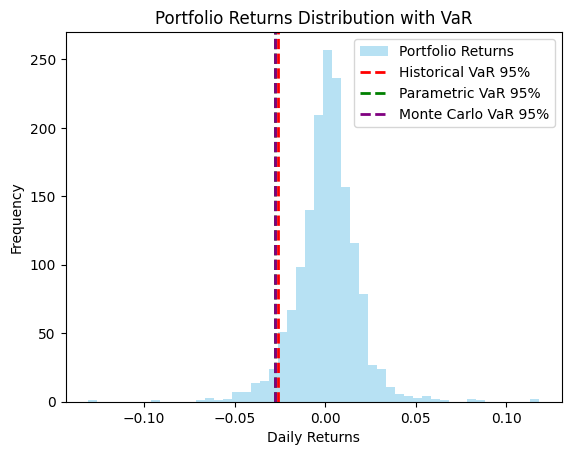

Number of Historical VaR breaches: 79


In [9]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np

assets = ['AAPL', 'MSFT', 'GOOGL']

data = yf.download(assets, start="2020-01-01")

prices = data['Close']

returns = prices.pct_change().dropna()
# Check available columns
print(data.columns)
weights = np.array([1/3, 1/3, 1/3])

portfolio_returns = returns.dot(weights)

portfolio_returns.head()
VaR_hist_95 = np.percentile(portfolio_returns, 5)
print("Historical VaR (95%):", VaR_hist_95)
from scipy.stats import norm

mean = portfolio_returns.mean()
std = portfolio_returns.std()

VaR_param_95 = norm.ppf(0.05, mean, std)
print("Parametric VaR (95%):", VaR_param_95)
simulations = 10000
simulated_returns = np.random.normal(mean, std, simulations)
VaR_mc_95 = np.percentile(simulated_returns, 5)
print("Monte Carlo VaR (95%):", VaR_mc_95)
import matplotlib.pyplot as plt

plt.hist(portfolio_returns, bins=50, alpha=0.6, color='skyblue', label='Portfolio Returns')
plt.axvline(VaR_hist_95, color='red', linestyle='dashed', linewidth=2, label='Historical VaR 95%')
plt.axvline(VaR_param_95, color='green', linestyle='dashed', linewidth=2, label='Parametric VaR 95%')
plt.axvline(VaR_mc_95, color='purple', linestyle='dashed', linewidth=2, label='Monte Carlo VaR 95%')
plt.title('Portfolio Returns Distribution with VaR')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

violations = (portfolio_returns < VaR_hist_95).sum()
print("Number of Historical VaR breaches:", violations)

